### Bande parabolique

Dans cette partie on test rapidement le schéma pour une bande de dispersion parabolique $\varepsilon(p) = \dfrac {\alpha p^2}{2}$.
On devrait alors retrouver des trajectoires sphériques dans l'espace des moments.

Calculons aussi la solution théorique:
En posant $G:=\dfrac{eB}{c}$ le problème de départ est : 
$$

\begin{cases}
p_x'(t) = G \left( \alpha p_y + v_d \right) \\
p_y'(t) = - G \alpha p_x
\end{cases}
$$
En dérivant la première ligne et en remplaçant $p_y'(t)$, on obtient:
$$ p_x''(t) + (G \times alpha)^2 \times p_x(t) = 0$$
D'où 
$$p_x(t) = A \cos(G \alpha t) + B \sin(G \alpha t)$$
avec A et B deux réels.
On suppose que au temps initial $P = (1, 0)$, alors $p_x(0) \Longrightarrow A = 1 $.

On repart ensuite de $p_y'(t)$ et on intègre par rapport à t on utilisant la forme de $p_x(t)$ obtenue on a:
$$
p_y(t) = \sin(G \alpha t) + B \cos(G \alpha t) + cst
$$ 
On en profite pour remarquer que comme $p_y(0) = 0$ on a : $B + cst = 0 $.

En utilisant la forme initial de $p_x'(t)$ et la forme obtenue en dérivant l'écriture avec le cosinus et le sinus puis en évaluant en 0 on trouve:
$$
\begin{aligned}
B G \alpha &= G v_d \\
B &= \dfrac{v_d}{\alpha}
\end{aligned}
$$
et donc $cst = -\dfrac{v_d}{\alpha}$.
On ainsi trouvé comme solution:
$$
\begin{cases}
p_x(t) = \cos(G \alpha t) + \dfrac{v_d}{\alpha} \sin(G \alpha t) \\
p_y(t) = \dfrac{v_d}{\alpha}\cos(G \alpha t) - \sin(G \alpha t) - \dfrac{v_d}{\alpha}
\end{cases}
$$


En redérivant on retrouve bien le problème de départ, la solution est correct.

In [2]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters
import time
from scipy.signal import find_peaks

Période : 8.975979010256552


        Computation finished in 1 seconds


Comparaison des méthodes avec alpha =  1 


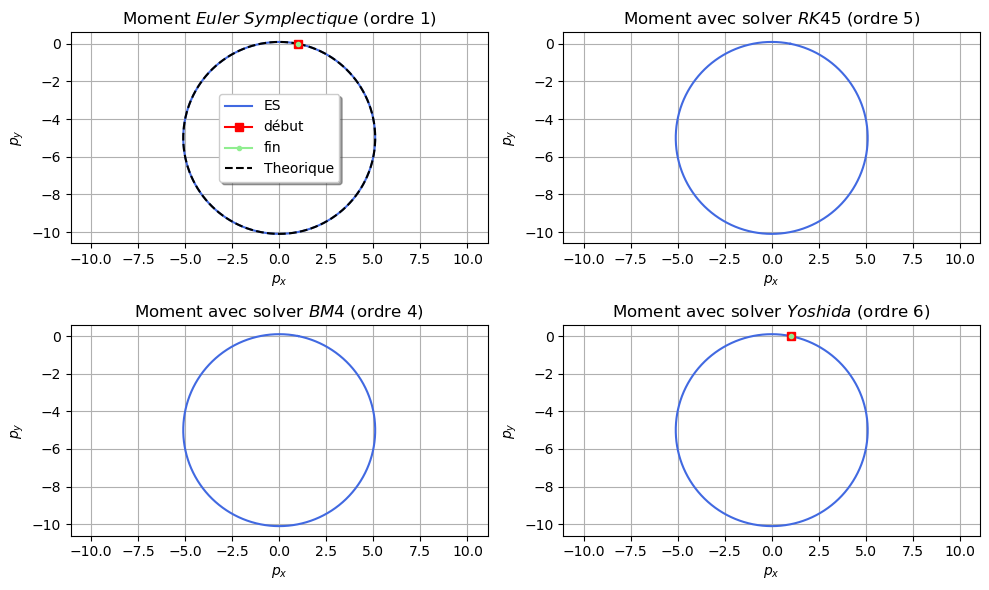

Période : 1.7951958020513104


        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  5 


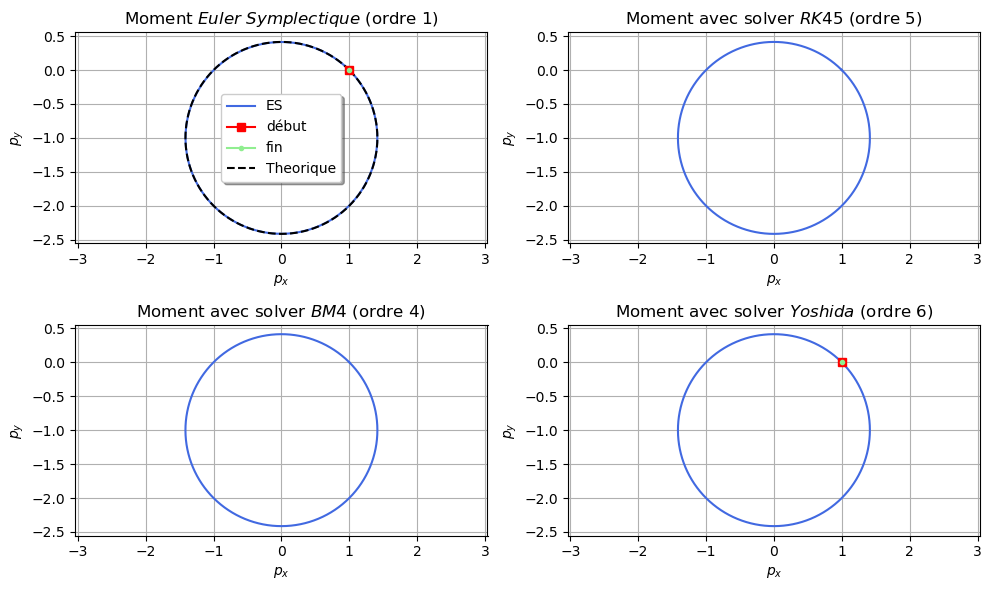

Période : 0.4487989505128276


        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  20 


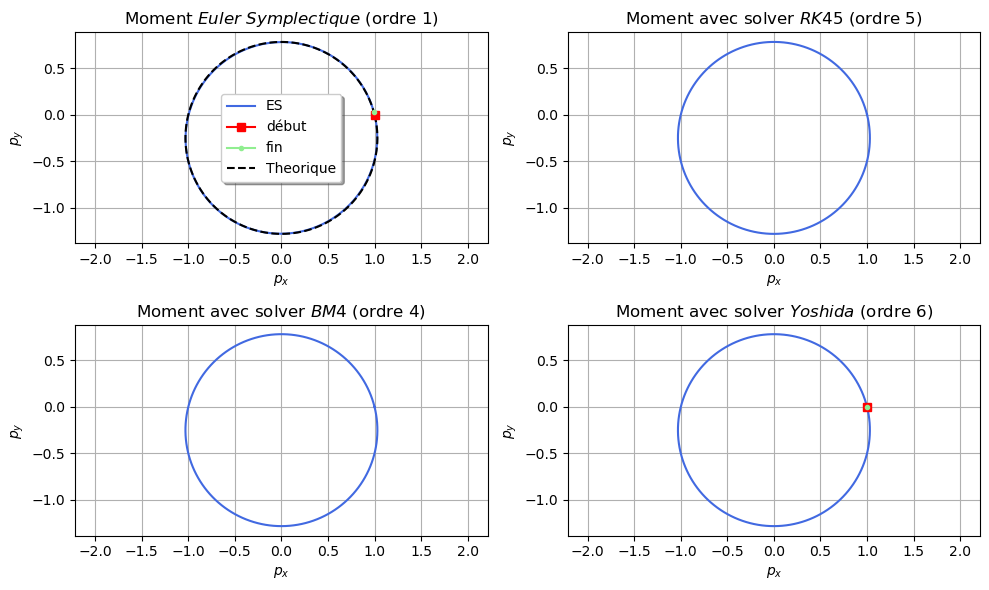

        Computation finished in 0 seconds


Période : 0.08975979010256552
Comparaison des méthodes avec alpha =  100 


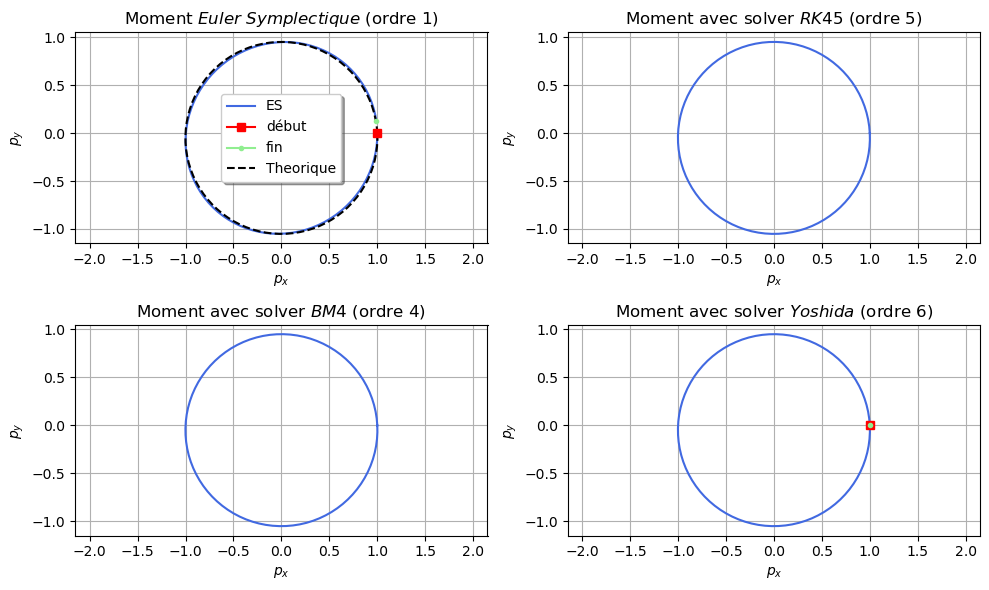

In [3]:
# Paramètre ---------------------------------------------------------------------------
# deltaT = 0.01
# T = 3* np.pi
# number_iter = T / deltaT
# time_range = np.linspace(0, T , int(number_iter)) 

P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 5
alpha_liste = [ 1, 5, 20, 100]

deltaT = 0.001
def W(P):
   return varepsilon_parabolique(P, alpha) + vd * P[1]

def omega_c(W):
   return (e * B / c) * ( vF**2 / W(P)) * (1 - vd/vF)**(3/2) 


# ----------------------------------------------------------------------------------------
def varepsilon_parabolique(p, alpha):
    px = p[0]
    py = p[1]
    
    return  alpha * (px**2 + py**2) / 2

def ES_parabolique(deltaT, T, P, e , B, c, alpha):
    G = deltaT * e * B * alpha / c
    Iteration_matrix = np.array([[1 - G**2, G], [-G, 1]])
    Drift_matrix = np.array([deltaT * e * B * vd /c, 0])
    N = int(np.floor(T / deltaT))
    P_trajectory = np.zeros((N, 2))
    
    P_trajectory[0] = P
    for i in range(1, N):
        P = Iteration_matrix @ P + Drift_matrix
        P_trajectory[i] = P
    return P_trajectory

   
def p_system(t, P): #resolution papier pour bande parabolique
    G =  e * B  / c
    return np.array( [G * (alpha * P[1] + vd)  , -G * alpha * P[0] ])
# ----------------------------------------------------------------------------------------------
# Ajout de la solution théorique
def theo_para(time_range, alpha):
    G = e * B / c

    px = np.cos(G * alpha * time_range) + vd / alpha * np.sin(G * alpha * time_range)
    py = vd / alpha * np.cos(G * alpha * time_range) - np.sin(G * alpha * time_range)  - vd / alpha

    return px, py

#---------------------------------------------------------------------------------------------------
hs = HamSys(ndof=1)
for i, alpha in enumerate(alpha_liste):
    
    T = 2 * np.pi / ((e * B / c) * alpha) # j'ai directement utilisé la défintion de px pour avoir omega
    print(f'Période : {T}')
    time_range = np.linspace(0, T , int((np.floor(T /deltaT))))

    hs.y_dot = p_system # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='Yos6'))

    Moment_ES = ES_parabolique(deltaT, T, P, e, B, c, alpha)

    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))

    sol_theorique = theo_para(time_range, alpha)
# Plot -------------------------------------------------------------------------------------------------

    print(f'Comparaison des méthodes avec alpha =  {alpha} ')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))

    ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
    ax1.plot(Moment_ES[0, 0], Moment_ES[0,1], marker='s', color='red',label='début', zorder=3)
    ax1.plot(Moment_ES[-1, 0], Moment_ES[-1,1], marker='.', color='lightgreen',label='fin', zorder=3)
    ax1.set_xlabel(r'$p_x$')
    ax1.set_ylabel(r'$p_y$')
    ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')  
    
    ax1.plot(sol_theorique[ 0], sol_theorique[1], linestyle='--', color='black',label='Theorique')  
    ax1.legend(shadow=True)
    # ax1.plot(sol_Verlet.y[0], sol_Verlet.y[1], color='royalblue',label='ES')
    # ax1.set_xlabel(r'$p_x$')
    # ax1.set_ylabel(r'$p_y$')
    # ax1.set_title(r'Moment solver $Verlet$ (ordre 2)') 


    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.plot(sol_Yoshida.y[0][0], sol_Yoshida.y[1][0], color='red', marker='s')
    ax4.plot(sol_Yoshida.y[0][-1], sol_Yoshida.y[1][-1], color='lightgreen', marker='.')
    
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    ax1.axis('equal'), ax2.axis('equal'), ax3.axis('equal'), ax4.axis('equal')

    plt.tight_layout()
    plt.show()

## Calcul des erreurs

        Computation finished in 0 seconds
        Computation finished in 0 seconds
        Computation finished in 0 seconds
        Computation finished in 0 seconds


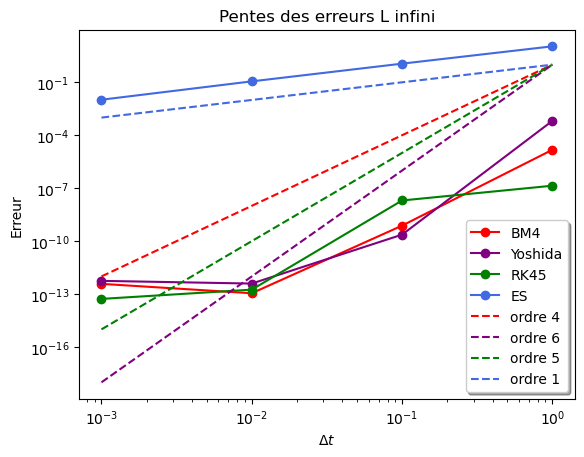

In [30]:
deltaT_tab = np.array([  1E-3, 1E-2, 1E-1, 1E0]) # 1E-3, 2E-3, 1E-2, 

T_periode = 2 * np.pi / ((e * B / c) * alpha)
T = 1 * T_periode
def Erreur(f1, f2):
    return np.max(np.abs(f1 - f2))

Erreur_sol_BM4 = []
Erreur_sol_Yoshida = []
Erreur_sol_ES = []
Erreur_sol_RK45 = []


for i, deltaT in enumerate(deltaT_tab):

    time_range = np.linspace(0, T , int(T / deltaT)) 
    hs.y_dot = p_system # choix du système

    # --- Calcul des solutions ------------------------------------------------------------------------------------------------
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T ), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='BM4',))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet')).y[1]
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
    Moment_ES = ES_parabolique(deltaT, T, P, e, B, c, alpha)
    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
    sol_theorique = theo_para(time_range, alpha)

    # --------------------------------------------------------------------------
    # print(f'THéorique = {np.round(sol_theorique,4)}')
    # print(f'BM4 = {np.round(sol_BM4,4)}')
    # print(f'ES = {np.round(Moment_ES,4)}')
    # print(f'Yoshida = {np.round(sol_Yoshida,4)}')
    # print(f'RK4 = {np.round(sol_RK45,4)}')

    # --- Calcul des erreurs ---------------------------------------------------------------------------------------------------
    Erreur_sol_BM4.append(Erreur(sol_theorique[1], sol_BM4.y[1]))
    Erreur_sol_Yoshida.append(Erreur(sol_theorique[1], sol_Yoshida.y[1]))
    Erreur_sol_ES.append(Erreur(sol_theorique[1], Moment_ES[:,1]))
    Erreur_sol_RK45.append(Erreur(sol_theorique[1], sol_RK45.y[1]))

plt.figure()
plt.loglog(deltaT_tab, Erreur_sol_BM4, marker='o', label='BM4', color='red')
plt.loglog(deltaT_tab, Erreur_sol_Yoshida, marker='o', label='Yoshida', color='purple')
plt.loglog(deltaT_tab, Erreur_sol_RK45, marker='o', label='RK45', color='green')
plt.loglog(deltaT_tab, Erreur_sol_ES, marker='o', label='ES', color='royalblue')

plt.loglog(deltaT_tab,  deltaT_tab**4, linestyle='--', color='red', label='ordre 4')
plt.loglog(deltaT_tab,  deltaT_tab**6, linestyle='--', color='purple', label='ordre 6')
plt.loglog(deltaT_tab,  deltaT_tab**5, linestyle='--', color='green', label='ordre 5')
plt.loglog(deltaT_tab, deltaT_tab, linestyle='--', color='royalblue', label='ordre 1')

plt.legend(shadow=True)
plt.title('Pentes des erreurs L infini')
plt.xlabel(r'$\Delta t$')
plt.ylabel('Erreur')
plt.show()


Const_Yoshida = np.mean(  np.array(Erreur_sol_Yoshida)[3:] / (deltaT_tab[3:]**6 * T) )
Const_RK45 = np.mean(  np.array(Erreur_sol_RK45)[3:] / (deltaT_tab[3:]**5 * T) )
Const_BM4 = np.mean(  np.array(Erreur_sol_BM4)[3:] / (deltaT_tab[3:]**4 * T) )

# print(f'Constante utilisé pour déterminé le delta t de Yoshida plus tard : {Const_Yoshida}')


Dans cette partie on cherche à étudier la période de notre système.

Périodes : [4.83322447 4.83321447 4.83322447]
Période moyenne : 4.833221133729427 
Période théorique : 4.83321946706122
Erreur sur la période : 1.6666682070010097e-06


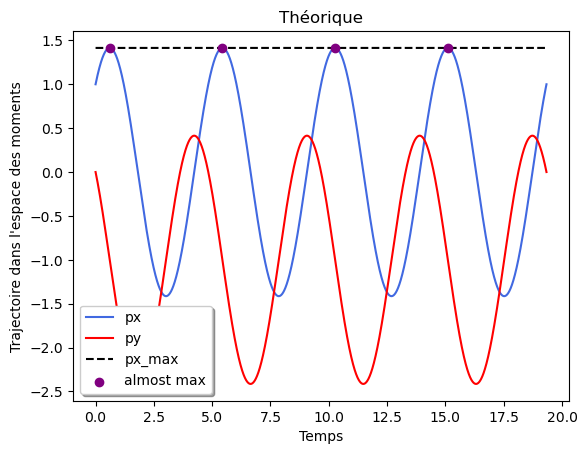

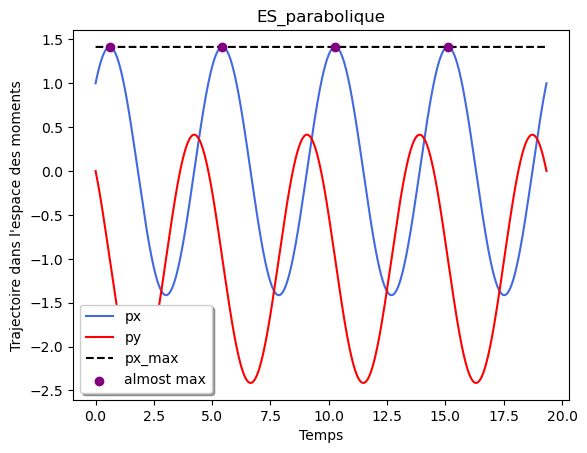

Valeurs max: [1.41420897 1.41420897 1.41420897 1.41420897]
Périodes : [4.83322447 4.83322447 4.83322447]
Période moyenne : 4.8332244670658415 
Période théorique : 4.83321946706122
Erreur sur la période : 5.0000046218912075e-06


In [21]:
alpha = int(1)
deltaT = 1E-5
T= 4 * (2 * np.pi / ((e * B / c) * alpha))
vd=1
time_range = np.linspace(0, T, int(T/deltaT))
# ------------THEORIQUE -------------------------------------
px, py = theo_para(time_range, alpha)
px_max = np.max(px) * np.ones_like(time_range)

pics, properties = find_peaks(px, height=np.mean(px))  

t_pics = time_range[pics]
valeurs_maxs = properties["peak_heights"]
periodes = np.diff(t_pics)
# --------------------------------------------------------
plt.figure()
plt.plot(time_range, px, color='royalblue', label='px')
plt.plot(time_range, py, color='red', label='py')
plt.plot(time_range, px_max, color='black', label='px_max', linestyle='--')
plt.scatter(t_pics, valeurs_maxs, marker='o', color="purple", zorder=3, label='almost max')
print(f"Périodes : {periodes}")
print(f"Période moyenne : {np.mean(periodes)} \nPériode théorique : {T/4}")
print(f'Erreur sur la période : {np.abs(np.mean(periodes) - T/4 )}')

plt.xlabel('Temps')
plt.ylabel('Trajectoire dans l\'espace des moments')
plt.legend(shadow=True, loc='lower left')
plt.title('Théorique')
plt.show()
# ------------ES PARABOLIQUE-------------------------------------------------------
vect = ES_parabolique(deltaT, T, P, e, B, c, alpha)
px, py =  vect[:,0], vect[:,1]

pics, properties = find_peaks(px, height=np.mean(px))  

t_pics = time_range[pics]
valeurs_maxs = properties["peak_heights"]
periodes = np.diff(t_pics)

# ---- plot ------------------------------------------------------
plt.plot(time_range, px, color='royalblue', label='px')
plt.plot(time_range, py, color='red', label='py')
plt.plot(time_range, px_max, color='black', label='px_max', linestyle='--')
plt.scatter(t_pics, valeurs_maxs, marker='o', color="purple", zorder=3, label='almost max')

plt.xlabel('Temps')
plt.ylabel('Trajectoire dans l\'espace des moments')
plt.legend(shadow=True, loc='lower left')
plt.title('ES_parabolique')
plt.show()

print(f'Valeurs max: {valeurs_maxs}')
print(f"Périodes : {periodes}")
print(f"Période moyenne : {np.mean(periodes)} \nPériode théorique : {T/4}")
print(f'Erreur sur la période : {np.abs(np.mean(periodes) - T/4 )}')

Une seconde façon plus théorique nous permet de calculer la période.
On utilise directement à la fois px et py pour trouver la période (voir papier de Lokta-Volterra)
Le résultat donne Période = $ \frac{2 \pi} {G \alpha}$

### Etude du pas de temps en fonction d'un seuil d'erreur et de la conservation d'énergie.

In [31]:
err = 1E-14
print(f'On impose un seuil d\'erreur de {err}')
G = e * B / c
T =  2 * np.pi *(e * B / c * alpha)
alpha=1
vd=0.3

def W(P):
   return varepsilon_parabolique(P, alpha) + vd * P[1]

# -----ES-----------------------------------------------------------------------
# deltaT_px = 2 * err / (T * (G**2 * alpha * np.sqrt(alpha**2 + vd**2)))
# deltaT_py = 2 * err / T * (((np.sqrt(2) * vd* alpha + 2 * np.sqrt(2) + 4 * vd) / ( 4*alpha)))
# deltaT = min(deltaT_px, deltaT_py)
# time_range = np.linspace(0, T , int(T / deltaT)) 

# start = time.perf_counter()
# Moment_ES = ES_parabolique(deltaT, T, P, e, B, c, alpha)
# end = time.perf_counter()
# time_ES = end - start

# sol_theorique = theo_para(time_range, alpha)

# Erreur_sol_ES = Erreur(sol_theorique[1], Moment_ES[:,1])

# W0 = W(P)
# Wf = W([Moment_ES[-1,0], Moment_ES[-1, 1]])

# print(f''' Schéma ES
#       Pas de temps: {deltaT}
#       Erreur schéma ES : {Erreur_sol_ES}
#       temps total pour execution de ES : {time_ES}
#       Temps théorique nécessaire via norme L inf : { 2 * Erreur_sol_ES / deltaT}
#       Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
# ''')

# ----YOSHIDA----------------------------------------------------------------------------
hs.y_dot = p_system # choix du système
deltaT = ( err / (T * Const_Yoshida))**(1/6)

time_range_yoshida = np.linspace(0, T, int(T/deltaT))

sol_theorique = theo_para(time_range_yoshida, alpha)

start = time.perf_counter()
sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range_yoshida, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
end = time.perf_counter()
time_Yoshida = end - start

Erreur_sol_Yoshida = Erreur(sol_theorique[1], sol_Yoshida.y[1])

W0 = W(P)
Wf = W([sol_Yoshida.y[0][-1], sol_Yoshida.y[1][-1]])

print(f''' Solver Yoshida 
      Pas de temps: {deltaT}
      Erreur schéma Yoshida : {Erreur_sol_Yoshida}
      temps total pour execution de Yoshida : {time_Yoshida}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')

# --- RK45 ------------------------------------------------------------------

deltaT = ( err / (T * Const_RK45))**(1/5)

time_range_RK45= np.linspace(0, T, int(T/deltaT))

sol_theorique = theo_para(time_range_RK45, alpha)

start = time.perf_counter()
sol_RK45 = hs.integrate( P, time_range_RK45, params=Parameters(step=deltaT, solver='RK45'))
end = time.perf_counter()
time_RK45 = end - start

Erreur_sol_RK45 = Erreur(sol_theorique[1], sol_RK45.y[1])
W0 = W(P)
Wf = W([sol_RK45.y[0][-1], sol_RK45.y[1][-1]])

print(f''' Solver RK45
      Pas de temps: {deltaT}
      Erreur schéma RK45 : {Erreur_sol_RK45}
      temps total pour execution de RK45 : {time_RK45}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')
# -- BM4 ------------------------------------------------------------------------
deltaT = ( err / (T * Const_BM4))**(1/4)
time_range_BM4= np.linspace(0, T, int(T/deltaT))

sol_theorique = theo_para(time_range_BM4, alpha)

start = time.perf_counter()
sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range_BM4, y0=P, params=Parameters(step=deltaT, solver='BM4'))
end = time.perf_counter()
time_BM4 = end - start

Erreur_sol_BM4 = Erreur(sol_theorique[1], sol_BM4.y[1])
W0 = W(P)
Wf = W([sol_BM4.y[0][-1], sol_BM4.y[1][-1]])

print(f''' Solver BM4
      Pas de temps: {deltaT}
      Erreur schéma BM4 : {Erreur_sol_BM4}
      temps total pour execution de BM4 : {time_BM4}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')


        Computation finished in 0 seconds


On impose un seuil d'erreur de 1e-14
 Solver Yoshida 
      Pas de temps: 0.018190630705709157
      Erreur schéma Yoshida : 1.8436641102681506e-14
      temps total pour execution de Yoshida : 0.1982908999780193
      Difference energie entre le debut et la fin = : 1.3322676295501878e-15

 Solver RK45
      Pas de temps: 0.04433180250479467
      Erreur schéma RK45 : 9.547495016803964e-10
      temps total pour execution de RK45 : 0.01368400000501424
      Difference energie entre le debut et la fin = : 1.0114870052646552e-09

 Solver BM4
      Pas de temps: 0.006304749388843876
      Erreur schéma BM4 : 1.021405182655144e-14
      temps total pour execution de BM4 : 0.421861499955412
      Difference energie entre le debut et la fin = : 8.881784197001252e-16



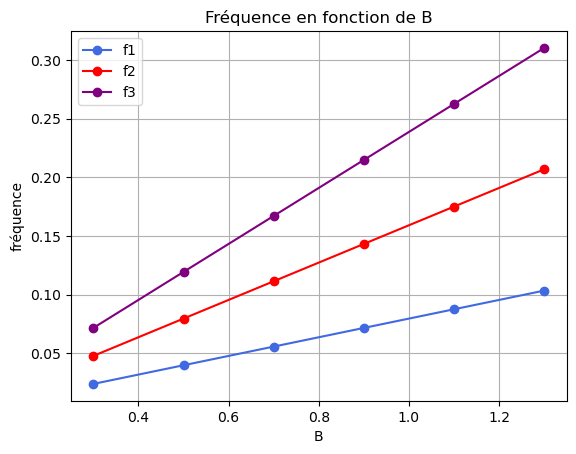

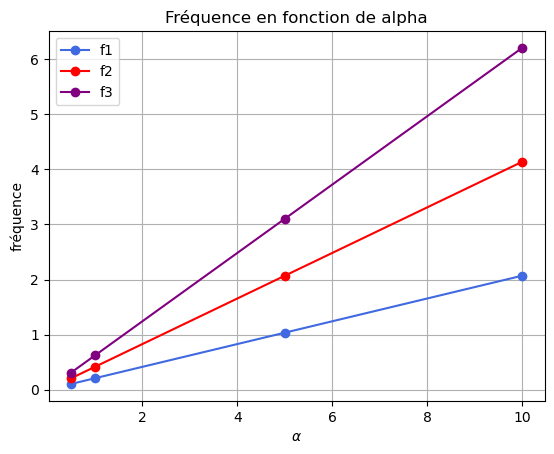

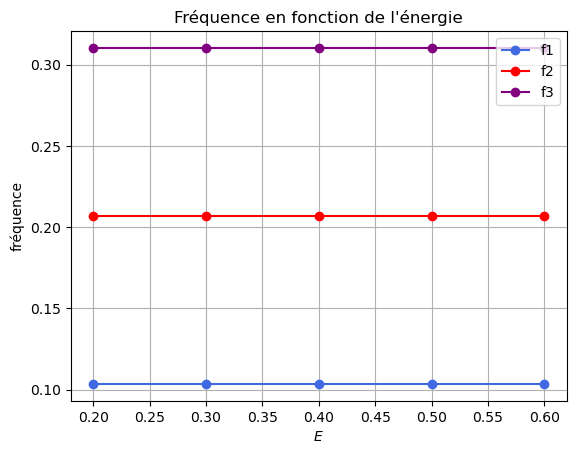

In [33]:
B_tab = np.array([0.3, 0.5, 0.7, 0.9, 1.1, 1.3])
periode_tab1 = np.zeros_like(B_tab)

for i, B in enumerate(B_tab):
    G = e * B / c
    T = 2 * np.pi / (G * alpha)
    periode_tab1[i] = T
frequence1 = 1 / periode_tab1
plt.figure()
plt.plot(B_tab, frequence1, marker='o', color='royalblue', label = "f1")
plt.plot(B_tab, 2 * frequence1, marker='o', color='red', label = "f2")
plt.plot(B_tab, 3 * frequence1, marker='o', color='purple', label= "f3")

plt.xlabel("B")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de B")
plt.legend()
plt.grid()
plt.show()
# ----------------------------------------------------------------------------
alpha_tab = np.array([ 0.5, 1, 5, 10])
periode_tab2 = np.zeros_like(alpha_tab)

for i, alpha in enumerate(alpha_tab):
    T = 2* np.pi /( G * alpha)
    periode_tab2[i] = T
frequence2 = 1 / periode_tab2
plt.figure()
plt.plot(alpha_tab, frequence2, marker='o', color='royalblue', label = "f1")
plt.plot(alpha_tab, 2 * frequence2, marker='o', color='red', label = "f2")
plt.plot(alpha_tab, 3 * frequence2, marker='o', color='purple', label= "f3")
plt.grid()

plt.xlabel(r"$\alpha$")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de alpha")
plt.legend()
plt.show()
# ------------------------------------------------------------------------------
E_tab = np.array([ 0.2, 0.3, 0.4, 0.5, 0.6])
periode_tab3 = np.zeros_like(E_tab)
alpha = 0.5
for i, E in enumerate(E_tab):
    E
    T = 2* np.pi /( G * alpha)
    periode_tab3[i] = T
frequence3 = 1 / periode_tab3
plt.figure()
plt.plot(E_tab, frequence3, marker='o', color='royalblue', label = "f1")
plt.plot(E_tab, 2 * frequence3, marker='o', color='red', label = "f2")
plt.plot(E_tab, 3 * frequence3, marker='o', color='purple', label= "f3")
plt.grid()

plt.xlabel(r"$E$")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de l'énergie")
plt.legend()
plt.show()
